# K-Means Clustering from Scratch

## Objectives

- Understand how K-Means clustering works.
- Implement K-Means using NumPy.
- Assign data points to the nearest centroid.
- Update centroids iteratively.
- Use the Elbow Method to select K.
- Compare the implementation with Scikit-Learn.

## K-Means Intuition

K-Means is an unsupervised learning algorithm that divides data into
K clusters.

Main steps:

1. Initialize K centroids.
2. Assign each point to its nearest centroid.
3. Recalculate each centroid using the mean of its assigned points.
4. Repeat until the centroids stop changing or the maximum number of
   iterations is reached.

The Euclidean distance is commonly used:

d(x, c) = √Σ(xᵢ - cᵢ)²

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [2]:
X, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df.head()

,Feature_1,Feature_2
0,-10.118757,9.078317
1,-5.128943,9.836189
2,-9.084071,7.050799
3,5.614999,1.826112
4,5.210769,3.108735


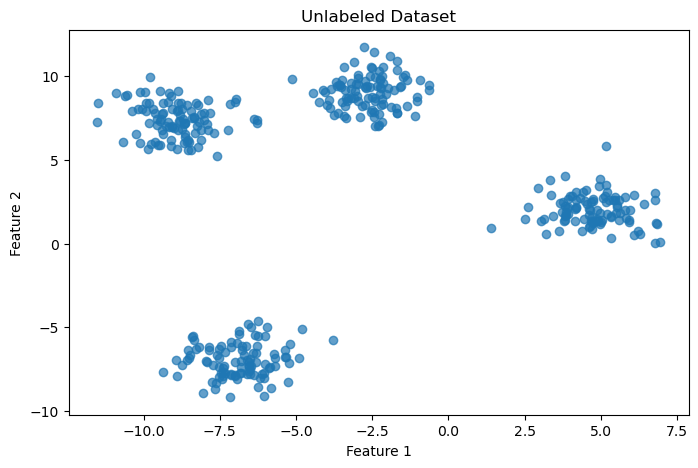

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unlabeled Dataset")

plt.show()

In [4]:
class KMeansScratch:
    def __init__(self, k=3, max_iterations=100, random_state=42):
        self.k = k
        self.max_iterations = max_iterations
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia = None

    def _initialize_centroids(self, X):
        rng = np.random.default_rng(self.random_state)

        indices = rng.choice(
            len(X),
            size=self.k,
            replace=False
        )

        return X[indices].copy()

    def _assign_clusters(self, X):
        distances = np.sqrt(
            ((X[:, np.newaxis, :] - self.centroids) ** 2).sum(axis=2)
        )

        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = []

        for cluster in range(self.k):
            cluster_points = X[labels == cluster]

            if len(cluster_points) == 0:
                new_centroids.append(self.centroids[cluster])
            else:
                new_centroids.append(cluster_points.mean(axis=0))

        return np.array(new_centroids)

    def _calculate_inertia(self, X, labels):
        total = 0

        for cluster in range(self.k):
            cluster_points = X[labels == cluster]

            if len(cluster_points) > 0:
                distances = cluster_points - self.centroids[cluster]
                total += np.sum(distances ** 2)

        return total

    def fit(self, X):
        X = np.asarray(X)

        if self.k < 1 or self.k > len(X):
            raise ValueError("k must be between 1 and the number of samples.")

        self.centroids = self._initialize_centroids(X)

        for _ in range(self.max_iterations):
            labels = self._assign_clusters(X)
            new_centroids = self._update_centroids(X, labels)

            if np.allclose(self.centroids, new_centroids):
                self.centroids = new_centroids
                break

            self.centroids = new_centroids

        self.labels = self._assign_clusters(X)
        self.inertia = self._calculate_inertia(X, self.labels)

        return self

    def predict(self, X):
        X = np.asarray(X)

        return self._assign_clusters(X)

In [5]:
kmeans = KMeansScratch(
    k=4,
    max_iterations=100,
    random_state=42
)

kmeans.fit(X)

labels = kmeans.labels

print("Centroids:")
print(kmeans.centroids)

print("\nInertia:", kmeans.inertia)

Centroids:
[[ 4.74710337  2.01059427]
 [-6.88387179 -6.98398415]
 [-2.63323268  9.04356978]
 [-8.92921104  7.38196067]]

Inertia: 766.5183043840314


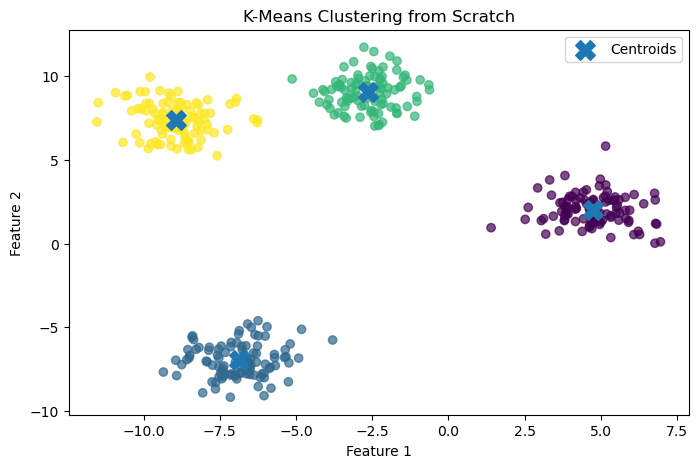

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    alpha=0.7
)

plt.scatter(
    kmeans.centroids[:, 0],
    kmeans.centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering from Scratch")
plt.legend()

plt.show()

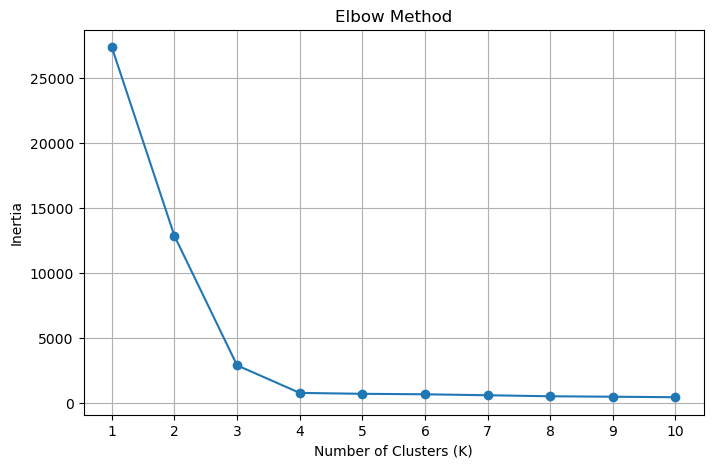

In [7]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeansScratch(
        k=k,
        max_iterations=100,
        random_state=42
    )

    model.fit(X)
    inertias.append(model.inertia)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [8]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeansScratch(
        k=k,
        max_iterations=100,
        random_state=42
    )

    model.fit(X)

    score = silhouette_score(X, model.labels)
    silhouette_scores.append(score)

best_k = list(range(2, 11))[
    np.argmax(silhouette_scores)
]

print("Best K based on Silhouette Score:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K based on Silhouette Score: 4
Best Silhouette Score: 0.7935062634483048


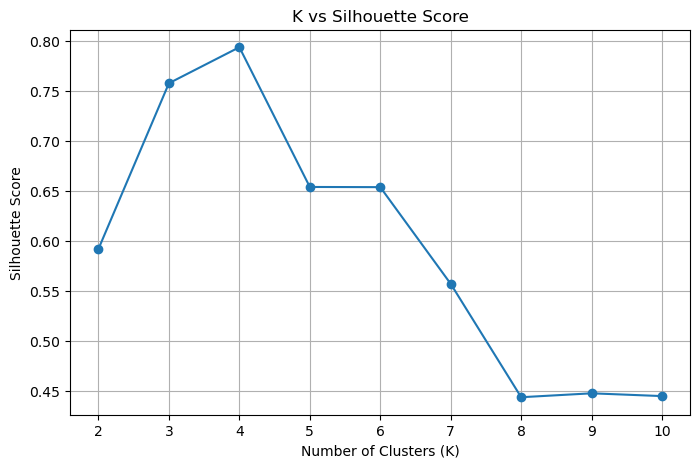

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K vs Silhouette Score")
plt.grid(True)

plt.show()

In [10]:
sklearn_kmeans = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=42
)

sklearn_labels = sklearn_kmeans.fit_predict(X)

comparison = pd.DataFrame({
    "Implementation": [
        "From Scratch",
        "Scikit-Learn"
    ],
    "Inertia": [
        kmeans.inertia,
        sklearn_kmeans.inertia_
    ],
    "Silhouette Score": [
        silhouette_score(X, labels),
        silhouette_score(X, sklearn_labels)
    ]
})

comparison

,Implementation,Inertia,Silhouette Score
0,From Scratch,766.518304,0.793506
1,Scikit-Learn,766.518304,0.793506


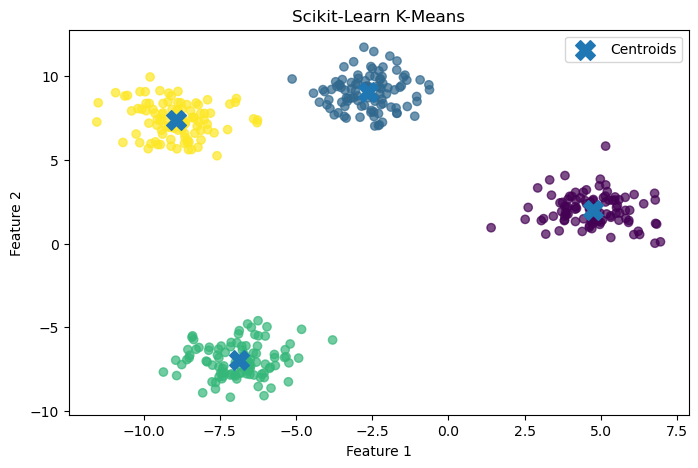

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=sklearn_labels,
    alpha=0.7
)

plt.scatter(
    sklearn_kmeans.cluster_centers_[:, 0],
    sklearn_kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scikit-Learn K-Means")
plt.legend()

plt.show()

## Conclusion

- K-Means is an unsupervised clustering algorithm.
- It assigns samples to the nearest centroid.
- Centroids are repeatedly updated until convergence.
- The Elbow Method can help identify a suitable K.
- The Silhouette Score provides another way to evaluate clustering quality.
- Different initial centroids can produce different results.
- K-Means works best when clusters are relatively compact and well separated.

## Limitations

- The number of clusters K must be selected.
- Results can depend on centroid initialization.
- K-Means can perform poorly with irregularly shaped clusters.
- Outliers can strongly affect centroid locations.